# Исследование результатов А/В-теста и поиск инсайтов

Автор: Вера Макухина

Дата: февраль 2026

SollmaFin — международное мобильное приложение для онлайн-торговли финансовыми активами. Пользователи могут инвестировать деньги в акции, валюту, криптовалюту, биржевые фонды (ETF) и другие активы. Целевая аудитория приложения — начинающие инвесторы. Получить доступ к финансовым рынкам можно со смартфона либо через веб-версию.

Приложение ориентировано на рынок Латинской Америки с акцентом на четыре страны: Мексику, Бразилию, Колумбию и Аргентину — там быстро растёт интерес к финтеху и инвестициям, а экономики очень разные.

Появилась гипотеза о недостаточной финансовой грамотности пользователей: они не понимают, как работать с активами разной степени риска. Клиенты покупают активы с высоким риском и теряют деньги, что снижает вовлечённость.
Команда продукта решила обновить онбординг пользователей и добавить в него детальную информацию о различиях финансовых активов и связанных с ними рисках. Однако появилось опасение, что углублённый онбординг отпугнёт клиентов от пополнения депозита и более рискованных вложений.

Чтобы разобраться, команда решила провести A/B-эксперимент.

### А/В-эксперимент

В эксперименте участвовали новые пользователи, которые зарегистрировались в приложении со 2 по 15 июня 2025 года.
Пользователей случайным образом разделили на две равные группы:
- Контрольная группа проходила стандартный онбординг без обязательного обучения.
- Тестовая группа проходила обновлённый онбординг с подробной информацией об активах и связанных с ними рисках.

После разделения активность пользователей анализировали в течение недели.

Цель эксперимента — оценить, как обновлённый онбординг влияет на поведение пользователей и их дальнейшую инвестиционную активность.

При внедрении новой фичи команда продукта выдвинула такие гипотезы:
- Гипотеза роста: обучающий онбординг помогает пользователям лучше понимать принципы инвестирования, поэтому они будут чаще открывать второй депозит.
- Гипотеза риска: информация о возможных потерях и высоких рисках отпугнёт некоторых новичков, особенно самых осторожных, что снизит конверсию в первый депозит.
- Дополнительная гипотеза: после нового онбординга пользователи, которые выбрали высокорискованные активы, будут чаще, чем раньше, возвращаться и открывать второй депозит. При старом онбординге пользователи часто покупали активы с высоким риском без понимания последствий. Это приводило к потерям и оттоку после первого депозита.

Для оценки эксперимента выбран следующий набор метрик:
- Ключевая метрика — средняя сумма всех депозитов на одного пользователя (включая тех, кто установил приложение или открыл веб-версию).
- Барьерная метрика — конверсия из регистрации в первый депозит.
- Вспомогательная метрика 1 — конверсия из первого депозита во второй.
- Вспомогательная метрика 2 — средняя сумма всех депозитов на пользователя, который открыл хотя бы один депозит.

Ожидалось, что ключевая и барьерная метрики не упадут, а вспомогательные покажут значительный рост.

### Структура анализа

1. Загрузка исторических данных и их предобработка
2. Исследовательский анализ исторических данных
3. Исследование результатов А/В-эксперимента
4. Анализ изменений суммы депозитов на платящего пользователя
5. Выводы

---

## О проекте

В этом проекте я исследовала результаты A/B-теста нового онбординга для финтех-приложения SollmaFin. Команда продукта обновила онбординг: добавила подробную информацию о финансовых активах и их рисках. Гипотеза — это поможет пользователям делать осознанные вложения и возвращаться за вторым депозитом.

Я проанализировала исторические данные о поведении пользователей, проверила корректность эксперимента, протестировала четыре продуктовые гипотезы и дала рекомендацию по внедрению фичи.

**Ключевые находки:**
- Конверсия из первого депозита во второй выросла на 61% в тестовой группе (статистически значимо)
- Барьерная метрика не ухудшилась — онбординг не отпугивает новых пользователей
- Bootstrap-анализ показал поляризацию: крупные инвесторы стали вкладывать больше, осторожные — меньше
- Ключевая метрика (ARPU) показывает положительную тенденцию, но статистически незначима — вероятно, двух недель эксперимента недостаточно

**Стек:** Python, pandas, numpy, scipy, statsmodels, matplotlib

---

## Часть 1

### 1. Загрузка исторических данных и их предобработка

In [1]:
# Импортирую библиотеки
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.stats.proportion import proportions_ztest
from scipy.stats import ttest_ind

In [2]:
# Функция для построения столбчатых диаграмм с подписями
def plot_bar_with_labels(df, x_col, y_col, title, ylabel, is_percent=False):
    plt.figure(figsize=(10, 5))
    
    bars = plt.bar(df[x_col], df[y_col])
    
    for bar, value in zip(bars, df[y_col]):
        label = f'{value * 100:.1f}%' if is_percent else f'{int(value)}'
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            value,
            label,
            ha='center',
            va='bottom'
        )
    
    plt.title(title)
    plt.ylabel(ylabel)
    plt.xlabel(x_col)
    plt.grid(axis='y')
    plt.tight_layout()
    plt.show()

In [3]:
# Загружаю данные, привожу даты к формату даты
df_hist = pd.read_csv('https://code.s3.yandex.net//datasets/pa_sollmafin_hist.csv', 
                      parse_dates=['first_ts', 'first_dt','event_ts'])

df_hist.info()
display(df_hist.head(3))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 238059 entries, 0 to 238058
Data columns (total 10 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   user_id       238059 non-null  object        
 1   country_code  238059 non-null  object        
 2   platform      238059 non-null  object        
 3   first_ts      238059 non-null  datetime64[ns]
 4   first_dt      238059 non-null  datetime64[ns]
 5   event_ts      238059 non-null  datetime64[ns]
 6   event_name    238059 non-null  object        
 7   amount        33093 non-null   float64       
 8   asset         15392 non-null   object        
 9   risk_level    15392 non-null   object        
dtypes: datetime64[ns](3), float64(1), object(6)
memory usage: 18.2+ MB


,user_id,country_code,platform,first_ts,first_dt,event_ts,event_name,amount,asset,risk_level
0,548ac59f-656d-4110-80d2-49f0a217f08a,BR,mobile,2025-04-02 19:55:51,2025-04-02,2025-04-02 19:55:51,install / open_web,NaN,NaN,NaN
1,548ac59f-656d-4110-80d2-49f0a217f08a,BR,mobile,2025-04-02 19:55:51,2025-04-02,2025-04-02 19:55:59,introduction,NaN,NaN,NaN
2,548ac59f-656d-4110-80d2-49f0a217f08a,BR,mobile,2025-04-02 19:55:51,2025-04-02,2025-04-02 23:46:06,registration,NaN,NaN,NaN


В таблице видно объединение нескольких источников, из-за чего появились пропуски в некоторых столбцах. В исторической таблице 238059 строк о пользователях, 33093 о пополнении депозитов и 15392 о приобретённых активах.

In [4]:
duplicates_hist = df_hist.duplicated().sum()
print(f'Количество явных дубликатов ист. данных: {duplicates_hist}')

first_date_hist = df_hist['first_dt'].min()
end_date_hist = df_hist['first_dt'].max()
print(f'Исторические данные о первом посещении пользователей с {first_date_hist} по {end_date_hist}')


Количество дубликатов ист. данных: 0
Исторические данные о первом посещении пользователей с 2025-04-01 00:00:00 по 2025-06-01 00:00:00


Явных дубликатов в данных нет, даты совпадают с датами из ТЗ.

In [5]:
# Проверяю данные на неявные дубликаты по полям 'user_id','event_ts','event_name'
duplicates_hist = df_hist.duplicated(subset=['user_id','event_ts','event_name'],keep=False).sum()
print(f'Количество строк с неявными дубликатами: {duplicates_hist}')

Количество строк с неявными дубликатами: 0


In [6]:
# Считаю в данных количество уникальных пользователей и вывожу уникальные поля в категориальных стролбцах

us_hist = df_hist['user_id'].nunique()
ev_hist = df_hist['event_name'].unique()
asset_hist = df_hist['asset'].unique()
risk_level_hist = df_hist['risk_level'].unique()
platform =  df_hist['platform'].unique()
country_code =  df_hist['country_code'].unique()

print(f'Количество уникальных пользователей в ист. данных: {us_hist}')
print(f'Названия событий: {ev_hist}')
print(f'Виды активов: {asset_hist}')
print(f'Уровни рисков: {risk_level_hist}')
print(f'Названия платформ: {platform}')
print(f'Код страны: {country_code}')

Количество уникальных пользователей в ист. данных: 41032
Названия событий: ['install / open_web' 'introduction' 'registration' 'main_page'
 'onboarding_complete' 'first_deposit' 'asset_purchase' 'second_deposit']
Виды активов: [nan 'stock' 'option' 'crypto']
Уровни рисков: [nan 'medium' 'high' 'low']
Названия платформ: ['mobile' 'web']
Код страны: ['BR' 'AR' 'CO' 'MX']


Данные проверены на явные и неявные дубликаты. Данные охватывают период с 1 апреля по 1 июня 2025 года.

Уникальных пользователей в исторических данных 41032.

Названия событий, виды активов и уровни рисков имеют корректные названия, без случайных дублей.

Уникальные значения в категориальных столбцах также проверены на некорректные данные, с ними всё в порядке.

---

### 2. Исследовательский анализ исторических данных

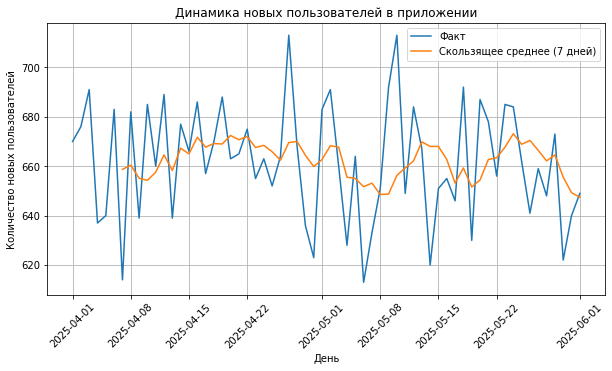

In [7]:
# Группирую новых пользователей по дате первого посещения приложения
new_us = df_hist.groupby('first_dt')['user_id'].nunique()

# Скользящее среднее за 7 дней
new_us_mean7 = new_us.rolling(window=7).mean()

# Визуализирую
plt.subplots(figsize=(10,5))

plt.plot(new_us, label='Факт')
plt.plot(new_us_mean7, label='Скользящее среднее (7 дней)')

plt.xticks(rotation=45)
plt.title('Динамика новых пользователей в приложении')
plt.xlabel('День')
plt.ylabel('Количество новых пользователей')

plt.legend()
plt.grid()
plt.show()

Приток новых пользователей стабилен и колеблется в диапазоне ~610-710 пользователей в день без выраженного тренда роста или падения. Наблюдаются регулярные недельные колебания, что может указывать на влияние поведенческой или маркетинговой сезонности. Это стоит учитывать при планировании маркетинговых кампаний.

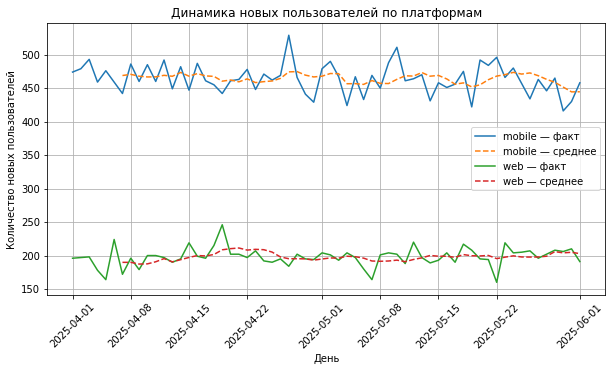

In [8]:
# Группирую новых пользователей по дате первого посещения и платформе
new_us_platform = (
    df_hist
    .groupby(['first_dt', 'platform'])['user_id']
    .nunique()
    .reset_index()
)

# Разворачиваю таблицу: даты — строки, платформы — колонки
new_us_platform_pivot = (
    new_us_platform
    .pivot(index='first_dt', columns='platform', values='user_id')
)

# Скользящее среднее за 7 дней
new_us_platform_mean7 = new_us_platform_pivot.rolling(window=7).mean()

# Визуализация
plt.subplots(figsize=(10, 5))

for platform in new_us_platform_pivot.columns:
    plt.plot(
        new_us_platform_pivot.index,
        new_us_platform_pivot[platform],
        label=f'{platform} — факт'
    )
    plt.plot(
        new_us_platform_mean7.index,
        new_us_platform_mean7[platform],
        linestyle='--',
        label=f'{platform} — среднее'
    )

plt.xticks(rotation=45)
plt.title('Динамика новых пользователей по платформам')
plt.xlabel('День')
plt.ylabel('Количество новых пользователей')

plt.legend()
plt.grid()
plt.show()


Основной приток новых пользователей идёт с mobile — мобильная платформа стабильно даёт в 2+ раза больше установок, чем web.

Динамика mobile более волатильна, тогда как web показывает ровный и стабильный поток без резких скачков. Mobile — основной канал роста; при принятии продуктовых решений приоритет стоит отдавать мобильному опыту.

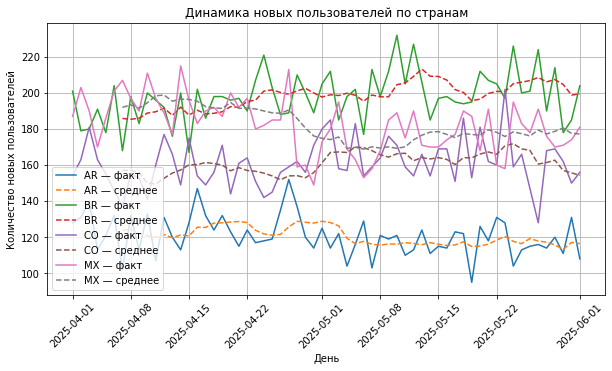

In [9]:
# Группирую новых пользователей по дате первого посещения и стране
new_us_country = (
    df_hist
    .groupby(['first_dt', 'country_code'])['user_id']
    .nunique()
    .reset_index()
)

# Разворачиваю таблицу: даты — строки, страны — колонки
new_us_country_pivot = (
    new_us_country
    .pivot(index='first_dt', columns='country_code', values='user_id')
)

# Скользящее среднее за 7 дней
new_us_country_mean7 = new_us_country_pivot.rolling(window=7).mean()

# Визуализация
plt.subplots(figsize=(10, 5))

for country in new_us_country_pivot.columns:
    plt.plot(
        new_us_country_pivot.index,
        new_us_country_pivot[country],
        label=f'{country} — факт'
    )
    plt.plot(
        new_us_country_mean7.index,
        new_us_country_mean7[country],
        linestyle='--',
        label=f'{country} — среднее'
    )

plt.xticks(rotation=45)
plt.title('Динамика новых пользователей по странам')
plt.xlabel('День')
plt.ylabel('Количество новых пользователей')

plt.legend()
plt.grid()
plt.show()


В разрезе стран лидером по притоку новых пользователей стабильно остаётся Бразилия (BR) — значения выше остальных на всём периоде.

Мексика (MX) и Колумбия (CO) показывают сопоставимую и достаточно стабильную динамику без выраженного тренда роста или падения.

Аргентина (AR) отстаёт по абсолютным значениям и демонстрирует более низкий и волатильный приток новых пользователей — это может указывать на специфику локального маркетинга или экономическую нестабильность.

,step,users,conversion,step_conversion
0,install / open_web,41032,1.000000,1.000000
1,introduction,41032,1.000000,1.000000
2,registration,38133,0.929348,0.929348
3,onboarding_complete,34337,0.836835,0.900454
4,first_deposit,27685,0.674717,0.806273
5,asset_purchase,15392,0.375122,0.555969
6,second_deposit,5408,0.131800,0.351351


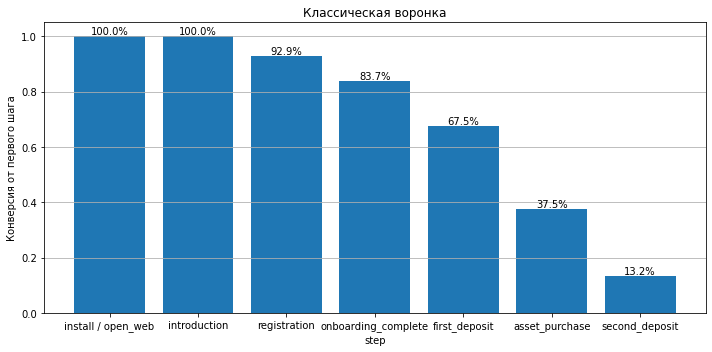

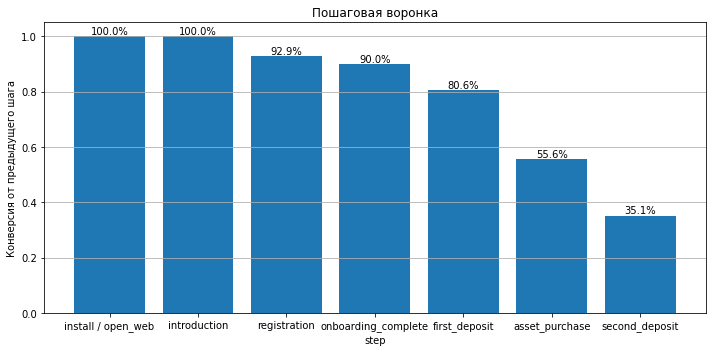

In [10]:
# Шаги воронки
steps = [
    'install / open_web',
    'introduction',
    'registration',
    'onboarding_complete',
    'first_deposit',
    'asset_purchase',
    'second_deposit'
]

# Количество пользователей на каждом шаге
funnel_counts = (
    df_hist[df_hist['event_name'].isin(steps)]
    .groupby('event_name')['user_id']
    .nunique()
    .reindex(steps)
    .reset_index()
)

funnel_counts.columns = ['step', 'users']

# Классическая конверсия
funnel_counts['conversion'] = funnel_counts['users'] / funnel_counts.loc[0, 'users']

# Пошаговая конверсия
funnel_counts['step_conversion'] = funnel_counts['users'] / funnel_counts['users'].shift(1)
funnel_counts.loc[0, 'step_conversion'] = 1

display(funnel_counts)

# Классическая воронка
plot_bar_with_labels(
    funnel_counts,
    x_col='step',
    y_col='conversion',
    title='Классическая воронка',
    ylabel='Конверсия от первого шага',
    is_percent=True
)

# Пошаговая воронка
plot_bar_with_labels(
    funnel_counts,
    x_col='step',
    y_col='step_conversion',
    title='Пошаговая воронка',
    ylabel='Конверсия от предыдущего шага',
    is_percent=True
)

Анализ воронки показал последовательное снижение числа пользователей на каждом этапе. Наиболее существенное падение наблюдается на переходе от первого депозита к покупке актива (пошаговая конверсия 55.6%), а также от покупки актива ко второму депозиту (35.1%). Итоговая конверсия от первого контакта с продуктом до второго депозита составляет 13.2%.

,platform,step,users,conversion,step_conversion
2,mobile,install / open_web,28758,1.000000,1.000000
3,mobile,introduction,28758,1.000000,1.000000
5,mobile,registration,26721,0.929168,0.929168
4,mobile,onboarding_complete,24008,0.834829,0.898469
1,mobile,first_deposit,19372,0.673621,0.806898
0,mobile,asset_purchase,10763,0.374261,0.555596
6,mobile,second_deposit,3809,0.132450,0.353898
9,web,install / open_web,12274,1.000000,1.000000
10,web,introduction,12274,1.000000,1.000000
12,web,registration,11412,0.929770,0.929770


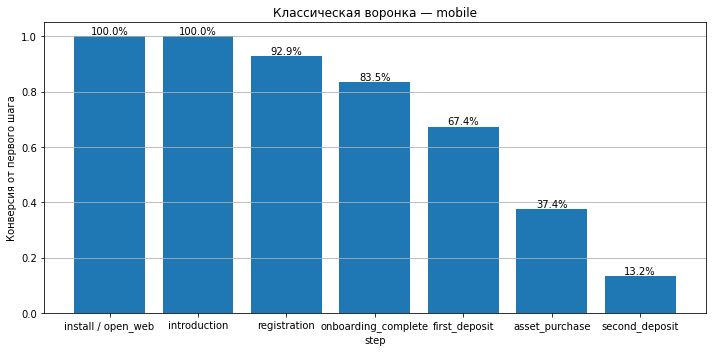

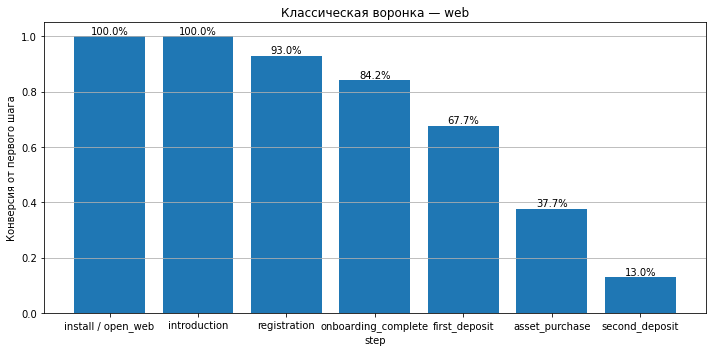

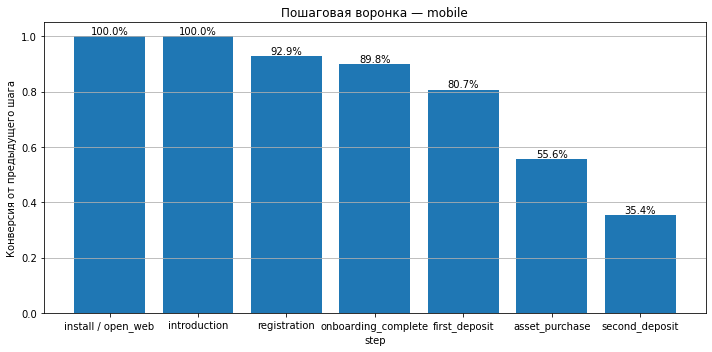

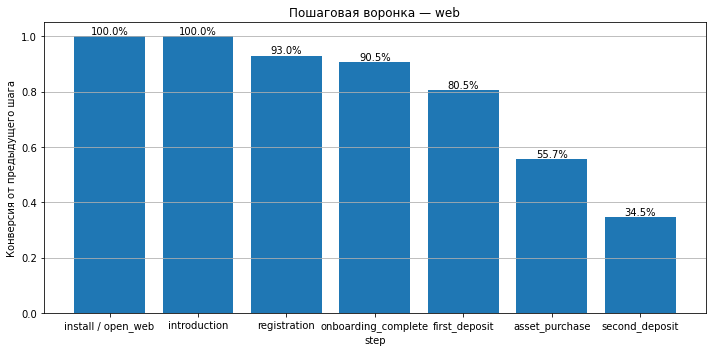

In [11]:
# Шаги воронки
steps = [
    'install / open_web',
    'introduction',
    'registration',
    'onboarding_complete',
    'first_deposit',
    'asset_purchase',
    'second_deposit'
]

# Количество пользователей на каждом шаге в разрезе платформ
funnel_platform = (
    df_hist[df_hist['event_name'].isin(steps)]
    .groupby(['platform', 'event_name'])['user_id']
    .nunique()
    .reset_index()
    .rename(columns={'event_name': 'step', 'user_id': 'users'})
)

funnel_platform['step'] = pd.Categorical(
    funnel_platform['step'],
    categories=steps,
    ordered=True
)

funnel_platform = funnel_platform.sort_values(['platform', 'step'])

# Классическая конверсия
funnel_platform['conversion'] = (
    funnel_platform['users'] /
    funnel_platform.groupby('platform')['users'].transform('first')
)

# Пошаговая конверсия
funnel_platform['step_conversion'] = (
    funnel_platform['users'] /
    funnel_platform.groupby('platform')['users'].shift(1)
)

funnel_platform.loc[
    funnel_platform.groupby('platform').head(1).index,
    'step_conversion'
] = 1

display(funnel_platform)


# Классическая воронка
for platform in funnel_platform['platform'].unique():
    df_plot = funnel_platform[funnel_platform['platform'] == platform]

    plot_bar_with_labels(
        df_plot,
        x_col='step',
        y_col='conversion',
        title=f'Классическая воронка — {platform}',
        ylabel='Конверсия от первого шага',
        is_percent=True
    )

# Пошаговая воронка  
for platform in funnel_platform['platform'].unique():
    df_plot = funnel_platform[funnel_platform['platform'] == platform]

    plot_bar_with_labels(
        df_plot,
        x_col='step',
        y_col='step_conversion',
        title=f'Пошаговая воронка — {platform}',
        ylabel='Конверсия от предыдущего шага',
        is_percent=True
    )


Воронка по платформам показывает схожую динамику на mobile и web. Конверсии на первых шагах высокие, 93%-84%, основное падение происходит на этапах asset_purchase и second_deposit. Значимых различий между платформами не наблюдается — пользователи обеих платформ ведут себя схоже на всех шагах.

,country_code,step,users,conversion,step_conversion
2,AR,install / open_web,7489,1.000000,1.000000
3,AR,introduction,7489,1.000000,1.000000
5,AR,registration,6997,0.934304,0.934304
4,AR,onboarding_complete,6345,0.847243,0.906817
1,AR,first_deposit,5072,0.677260,0.799370
0,AR,asset_purchase,2811,0.375351,0.554219
6,AR,second_deposit,1018,0.135933,0.362149
9,BR,install / open_web,12266,1.000000,1.000000
10,BR,introduction,12266,1.000000,1.000000
12,BR,registration,11382,0.927931,0.927931


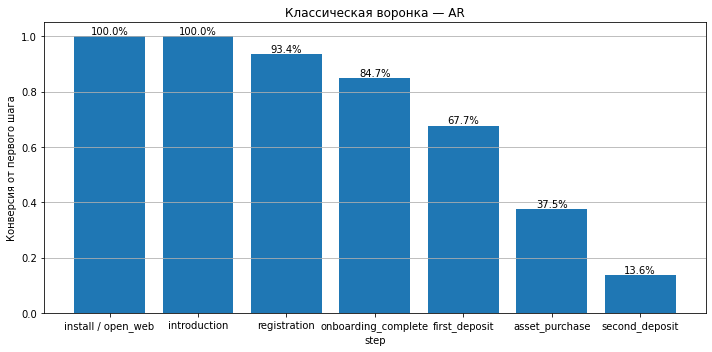

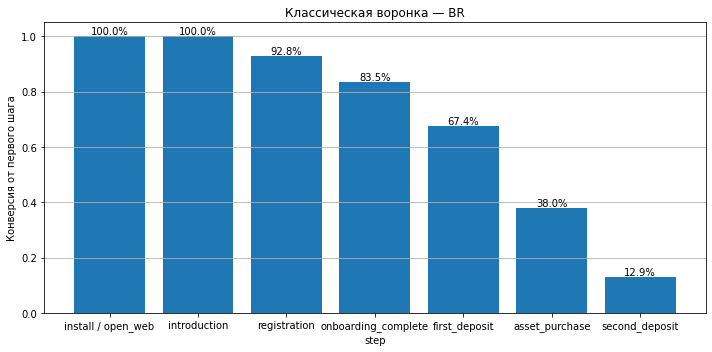

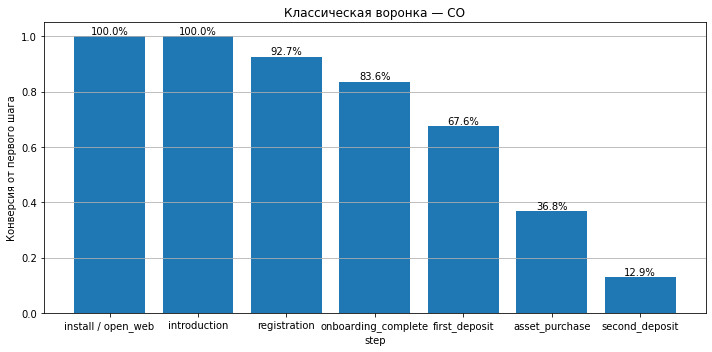

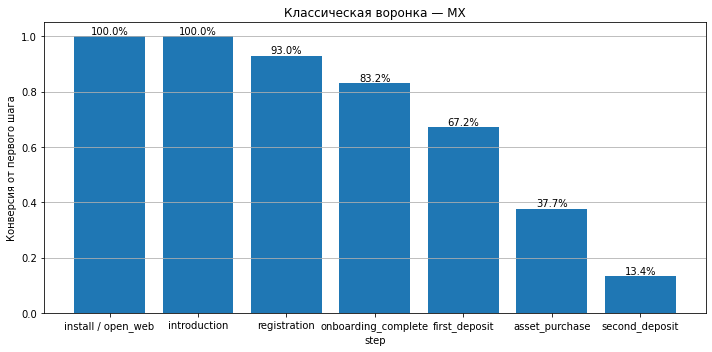

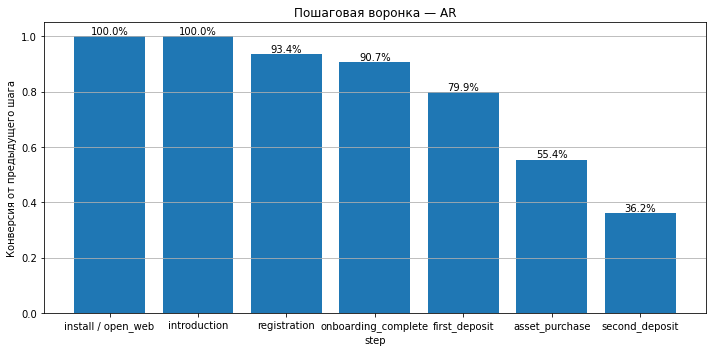

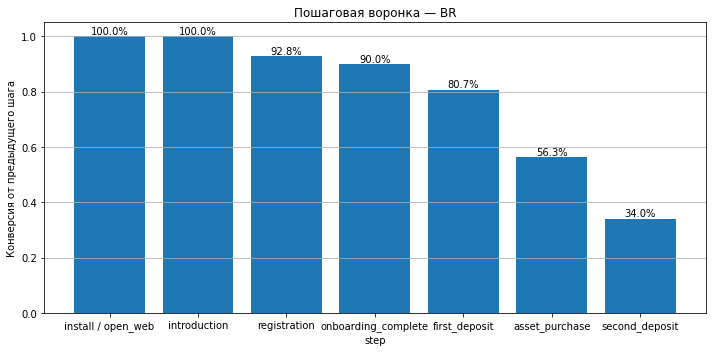

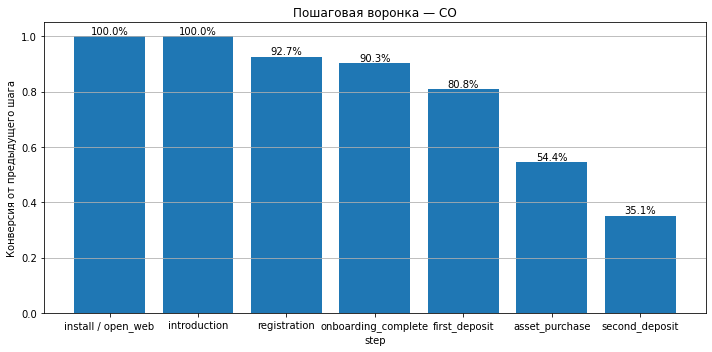

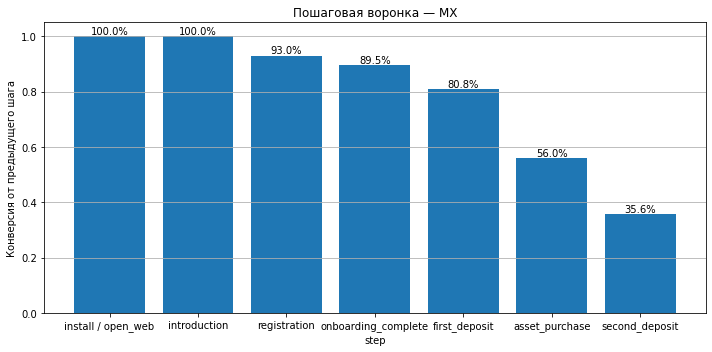

In [12]:
# Шаги воронки
steps = [
    'install / open_web',
    'introduction',
    'registration',
    'onboarding_complete',
    'first_deposit',
    'asset_purchase',
    'second_deposit'
]

# Количество пользователей на каждом шаге в разрезе стран
funnel_country = (
    df_hist[df_hist['event_name'].isin(steps)]
    .groupby(['country_code', 'event_name'])['user_id']
    .nunique()
    .reset_index()
    .rename(columns={'event_name': 'step', 'user_id': 'users'})
)

funnel_country['step'] = pd.Categorical(
    funnel_country['step'],
    categories=steps,
    ordered=True
)

funnel_country = funnel_country.sort_values(['country_code', 'step'])

# Классическая конверсия
funnel_country['conversion'] = (
    funnel_country['users'] /
    funnel_country.groupby('country_code')['users'].transform('first')
)

# Пошаговая конверсия
funnel_country['step_conversion'] = (
    funnel_country['users'] /
    funnel_country.groupby('country_code')['users'].shift(1)
)

funnel_country.loc[
    funnel_country.groupby('country_code').head(1).index,
    'step_conversion'
] = 1

display(funnel_country)

# Визуализация классической воронки 
for country in funnel_country['country_code'].unique():
    df_plot = funnel_country[funnel_country['country_code'] == country]

    plot_bar_with_labels(
        df_plot,
        x_col='step',
        y_col='conversion',
        title=f'Классическая воронка — {country}',
        ylabel='Конверсия от первого шага',
        is_percent=True
    )

# Визуализация пошаговой воронки 
for country in funnel_country['country_code'].unique():
    df_plot = funnel_country[funnel_country['country_code'] == country]

    plot_bar_with_labels(
        df_plot,
        x_col='step',
        y_col='step_conversion',
        title=f'Пошаговая воронка — {country}',
        ylabel='Конверсия от предыдущего шага',
        is_percent=True
    )


Конверсия на каждом шаге воронки схожа во всех странах, но доля пользователей, доходящих до второго депозита, немного выше в Аргентине и чуть ниже в Бразилии.
В целом поведение пользователей по шагам воронки стабильно, различия между странами небольшие.

,risk_level,users,users_with_second_deposit,conversion_to_second_deposit
1,low,2327,1080,0.464117
2,medium,5325,2288,0.429671
0,high,7740,2040,0.263566


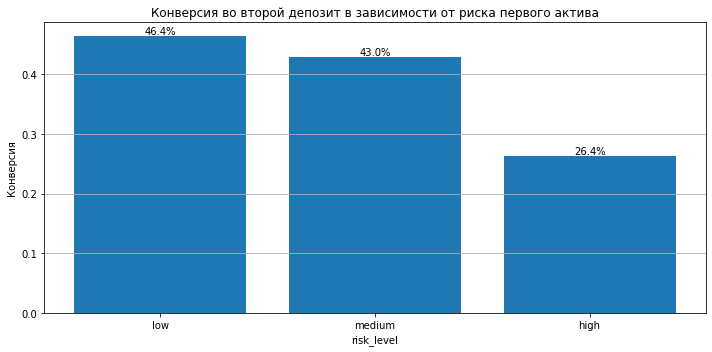

In [13]:
# Создаю таблицу с первым активом каждого пользователя и его уровнем риска
first_asset = (
    df_hist[df_hist['event_name'] == 'asset_purchase']
    .sort_values('event_ts')
    .groupby('user_id', as_index=False)
    .first()[['user_id', 'risk_level']]
)

# Обозначаю пользователей со вторым депозитом
first_asset['has_second_deposit'] = first_asset['user_id'].isin(
    df_hist.loc[df_hist['event_name'] == 'second_deposit', 'user_id']
)

# Группирую и считаю конверсию
conversion_by_risk = (
    first_asset
    .groupby('risk_level', observed=True)
    .agg(
        users=('user_id', 'nunique'),
        users_with_second_deposit=('has_second_deposit', 'sum')
    )
    .assign(conversion_to_second_deposit=lambda x: x['users_with_second_deposit'] / x['users'])
    .reset_index()
)

# Сортирую в нужном поряжке
risk_order = ['low', 'medium', 'high']
conversion_by_risk['risk_level'] = pd.Categorical(
    conversion_by_risk['risk_level'],
    categories=risk_order,
    ordered=True
)
conversion_by_risk = conversion_by_risk.sort_values('risk_level')

display(conversion_by_risk)

# Визуализирую через функцию
plot_bar_with_labels(
    conversion_by_risk,
    x_col='risk_level',
    y_col='conversion_to_second_deposit',
    title='Конверсия во второй депозит в зависимости от риска первого актива',
    ylabel='Конверсия',
    is_percent=True
)

Конверсия во второй депозит убывает с ростом уровня риска первого актива. Максимальное значение наблюдается у пользователей, выбравших активы с низким риском (46.4%), минимальное — у пользователей с высоким риском (26.4%). Это может указывать на более осторожное и последовательное поведение пользователей, начинающих с низкорисковых активов.

ARPU (средняя сумма депозитов на пользователя): 91.56
count    41032.000000
mean        91.562220
std         80.393251
min          0.000000
25%          0.000000
50%         96.000000
75%        133.000000
max        656.000000
Name: amount, dtype: float64


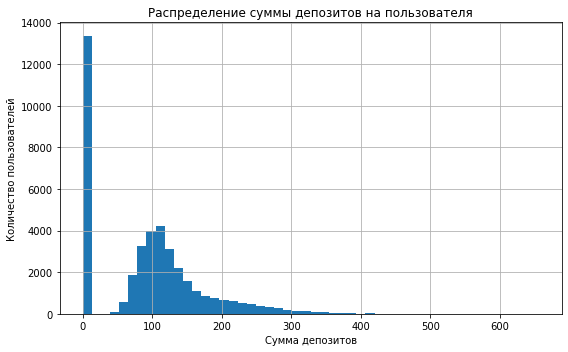

In [14]:
# Все пользователи и сумма всех депозитов
total_users = df_hist['user_id'].nunique()
total_amount = df_hist['amount'].fillna(0).sum()

# ARPU
arpu = total_amount / total_users

print(f'ARPU (средняя сумма депозитов на пользователя): {arpu:.2f}')

# Сумма депозитов на пользователя
user_deposits = (
    df_hist
    .groupby('user_id')['amount']
    .sum()
)
print(user_deposits.describe())

# Визуализирую
plt.figure(figsize=(8, 5))
plt.hist(user_deposits, bins=50)
plt.title('Распределение суммы депозитов на пользователя')
plt.xlabel('Сумма депозитов')
plt.ylabel('Количество пользователей')
plt.grid(True)
plt.tight_layout()
plt.show()

Средняя сумма депозитов на пользователя (ARPU) составляет 91.56. Распределение депозитов неравномерное: не менее 25% пользователей не совершают пополнений, при этом медианное значение (96) близко к среднему, что указывает на отсутствие сильного смещения метрики за счёт экстремальных значений. Основная масса пользователей вносит умеренные суммы, а максимальные депозиты достигают 656.

Теперь посчитаю те же данные, но с фильтрацией по 99 перцентилю.

ARPU с фильтром 99-го перцентиля: 88.88
count    40625.000000
mean        88.884923
std         76.087258
min          0.000000
25%          0.000000
50%         95.000000
75%        132.000000
max        318.000000
Name: amount, dtype: float64


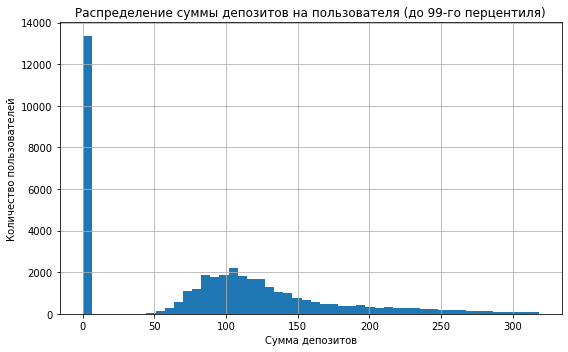

In [15]:
# 99-й перцентиль суммы депозитов
p99 = np.percentile(user_deposits, 99)

# Фильтрую пользователей до 99-го перцентиля
user_deposits_filtered = user_deposits[user_deposits <= p99]

# ARPU для фильтрованных данных
arpu_filtered = user_deposits_filtered.mean()

print(f'ARPU с фильтром 99-го перцентиля: {arpu_filtered:.2f}')
print(user_deposits_filtered.describe())

# Визуализация 
plt.figure(figsize=(8, 5))
plt.hist(user_deposits_filtered, bins=50)
plt.title('Распределение суммы депозитов на пользователя (до 99-го перцентиля)')
plt.xlabel('Сумма депозитов')
plt.ylabel('Количество пользователей')
plt.grid(True)
plt.tight_layout()
plt.show()

Без фильтрации: ARPU = 91.56, стандартное отклонение = 80.39.

С фильтром 99-го перцентиля: ARPU = 88.88, стандартное отклонение уменьшилось до 76.09.

Фильтрация показала более стабильную оценку среднего дохода на пользователя. 

Исторический ARPU = 91.56 используется как baseline для сравнения с результатами А/В-эксперимента в части 2.

---

## Часть 2

### 3. Исследование результатов А/В-эксперимента

In [16]:
df_abt = pd.read_csv('https://code.s3.yandex.net//datasets/pa_sollmafin_abt.csv', 
                      parse_dates=['first_ts', 'first_dt','event_ts'])

df_abt.info()
display(df_abt.head(3))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54805 entries, 0 to 54804
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   user_id       54805 non-null  object        
 1   country_code  54805 non-null  object        
 2   platform      54805 non-null  object        
 3   first_ts      54805 non-null  datetime64[ns]
 4   first_dt      54805 non-null  datetime64[ns]
 5   event_ts      54805 non-null  datetime64[ns]
 6   event_name    54805 non-null  object        
 7   ab_test       54805 non-null  object        
 8   group         54805 non-null  object        
 9   amount        7843 non-null   float64       
 10  asset         3750 non-null   object        
 11  risk_level    3750 non-null   object        
dtypes: datetime64[ns](3), float64(1), object(8)
memory usage: 5.0+ MB


,user_id,country_code,platform,first_ts,first_dt,event_ts,event_name,ab_test,group,amount,asset,risk_level
0,c430acb5-c6bf-43cf-8e2d-7ab9ce0d2c8a,BR,mobile,2025-06-07 19:55:51,2025-06-07,2025-06-07 19:55:51,install / open_web,onboarding_test,test,NaN,NaN,NaN
1,c430acb5-c6bf-43cf-8e2d-7ab9ce0d2c8a,BR,mobile,2025-06-07 19:55:51,2025-06-07,2025-06-07 19:55:54,introduction,onboarding_test,test,NaN,NaN,NaN
2,c430acb5-c6bf-43cf-8e2d-7ab9ce0d2c8a,BR,mobile,2025-06-07 19:55:51,2025-06-07,2025-06-08 06:18:09,registration,onboarding_test,test,NaN,NaN,NaN


В таблице с AB тестом информация о действиях пользователей 54805 строк, о пополнении депозитов 7843 и о купленных активах 3750.

In [17]:
duplicates_abt = df_abt.duplicated().sum()
print(f'Количество дубликатов в данных AB теста: {duplicates_abt}')

# Диапазон исторических данных (из df_hist)
hist_min = df_hist['first_dt'].min()
hist_max = df_hist['first_dt'].max()
print(f'Исторические данные о первом посещении пользователей с {hist_min} по {hist_max}')

# Диапазон данных А/В-теста
first_date_abt = df_abt['first_dt'].min()
end_date_abt = df_abt['first_dt'].max()
print(f'Данные о первом посещении пользователей AB теста с {first_date_abt} по {end_date_abt}')

Количество дубликатов в данных AB теста: 0
Исторические данные о первом посещении пользователей с 2025-04-01 00:00:00 по 2025-06-01 00:00:00
Данные о первом посещении пользователей AB теста с 2025-06-02 00:00:00 по 2025-06-15 00:00:00


Явных дубликатов в данных нет, даты совпадают с датами из ТЗ.

In [18]:
# Проверяю данные на неявные дубликаты по полям 'user_id','event_ts','event_name'
duplicates_abt = df_abt.duplicated(subset=['user_id','event_ts','event_name'],keep=False).sum()
print(f'Количество строк с неявными дубликатами: {duplicates_abt}')

Количество строк с неявными дубликатами: 0


In [19]:
us_abt = df_abt['user_id'].nunique()
ev_abt = df_abt['event_name'].unique()
asset_abt = df_abt['asset'].unique()
risk_level_abt = df_abt['risk_level'].unique()
print(f'Количество уникальных пользователей в эксперименте: {us_abt}')
print(f'Названия событий: {ev_abt}')
print(f'Виды активов: {asset_abt}')
print(f'Уровни рисков: {risk_level_abt}')

Количество уникальных пользователей в эксперименте: 9415
Названия событий: ['install / open_web' 'introduction' 'registration' 'main_page'
 'onboarding_complete' 'first_deposit' 'asset_purchase' 'second_deposit']
Виды активов: [nan 'crypto' 'stock' 'option']
Уровни рисков: [nan 'high' 'low' 'medium']


Данные проверены на явные и неявные дубликаты. Данные охватывают период с 2 по 15 июня 2025 года.

Уникальных пользователей в эксперименте 9415.

Названия событий, виды активов и уровни рисков имеют корректные названия, без случайных дублей. Совпадают с названиями в исторических данных.

,group,users,share
0,control,4847,0.514817
1,test,4568,0.485183


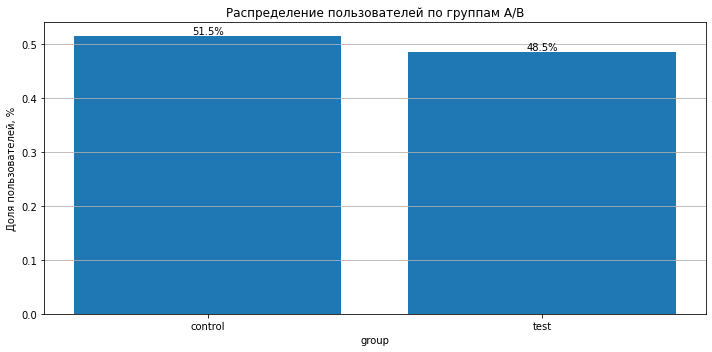

In [20]:
# Количество уникальных пользователей по группам
users_by_group = (
    df_abt
    .groupby('group')['user_id']
    .nunique()
    .reset_index(name='users')
)

# Доля пользователей
users_by_group['share'] = users_by_group['users'] / users_by_group['users'].sum()

# Визуализация
display(users_by_group)

plot_bar_with_labels(
    users_by_group,
    x_col='group',
    y_col='share',
    title='Распределение пользователей по группам A/B',
    ylabel='Доля пользователей, %',
    is_percent=True
)

Пользователи распределены между группами А/В почти поровну: контрольная группа — 51,5%, тестовая — 48,5%. Сильного перекоса нет, эксперимент можно считать сбалансированным.

,platform,group,users,share
0,mobile,control,3385,0.510481
1,mobile,test,3246,0.489519
2,web,control,1462,0.525144
3,web,test,1322,0.474856


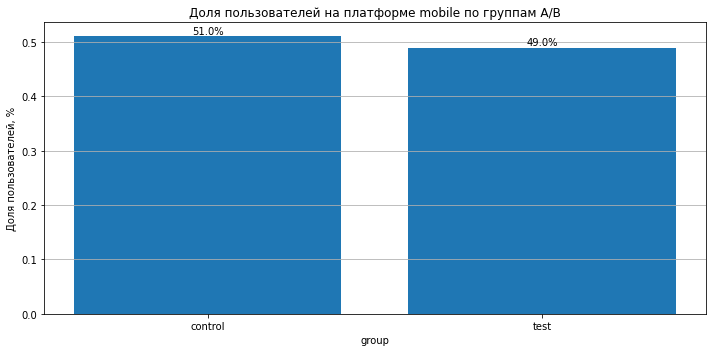

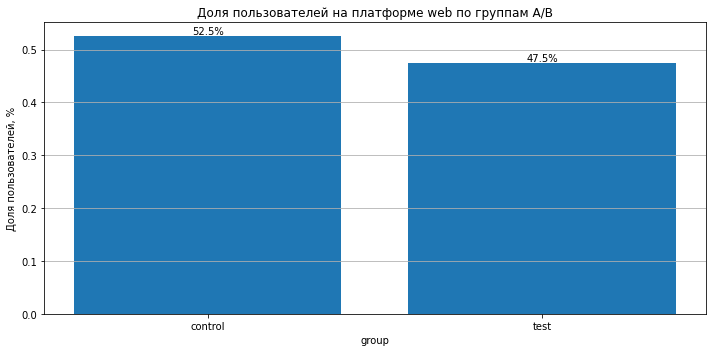

In [21]:
# Количество уникальных пользователей по группе и платформе
users_by_group_platform = (
    df_abt
    .groupby(['platform', 'group'])['user_id']
    .nunique()
    .reset_index(name='users')
)

# Доля пользователей внутри платформы (A + B = 100%)
users_by_group_platform['share'] = users_by_group_platform.groupby('platform')['users'].transform(lambda x: x / x.sum())

# Визуализация
display(users_by_group_platform)

for platform in users_by_group_platform['platform'].unique():
    df_plot = users_by_group_platform[users_by_group_platform['platform'] == platform]
    
    plot_bar_with_labels(
        df_plot,
        x_col='group',
        y_col='share',
        title=f'Доля пользователей на платформе {platform} по группам A/B',
        ylabel='Доля пользователей, %',
        is_percent=True
    )


Мобильные пользователи распределены почти поровну между группами A и B (51% контроль / 49% тест), на вебе доля контрольной группы чуть выше — 52% против 48% в тесте.

,country_code,group,users,share
0,AR,control,756,0.510466
1,AR,test,725,0.489534
2,BR,control,1543,0.515881
3,BR,test,1448,0.484119
4,CO,control,1247,0.509812
5,CO,test,1199,0.490188
6,MX,control,1301,0.521025
7,MX,test,1196,0.478975


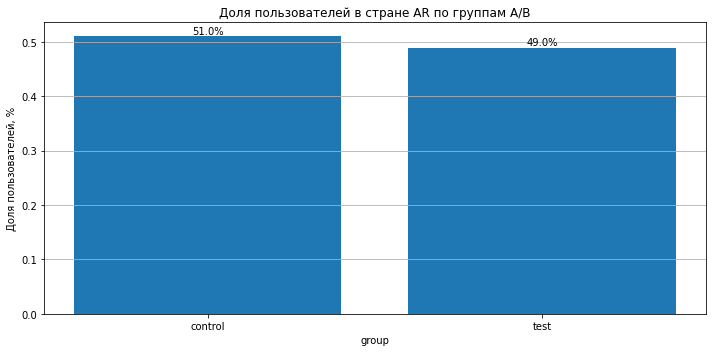

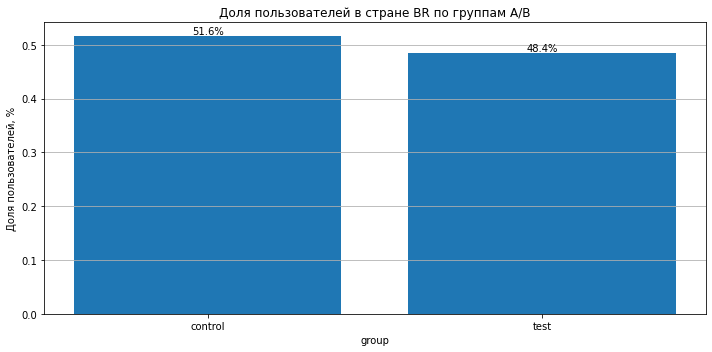

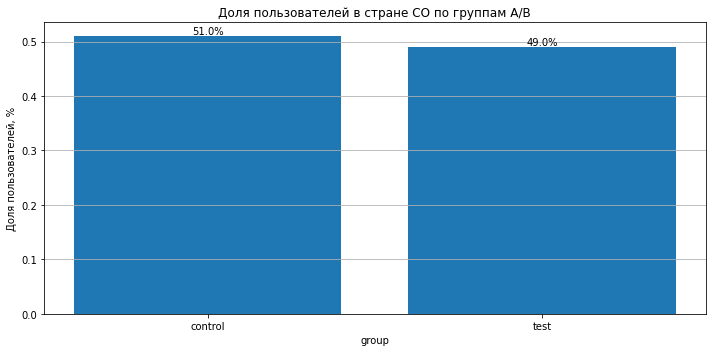

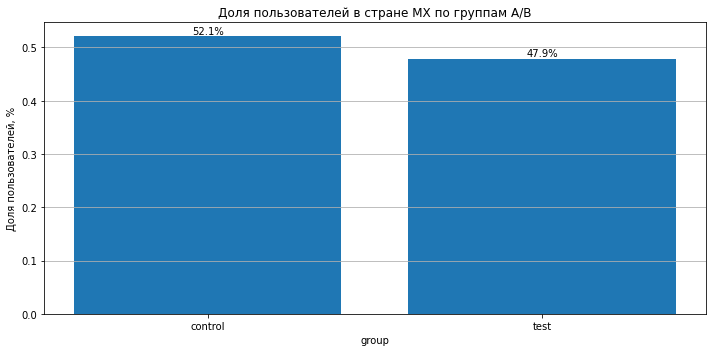

In [22]:
# Количество уникальных пользователей по стране и группе
users_by_group_country = (
    df_abt
    .groupby(['country_code', 'group'])['user_id']
    .nunique()
    .reset_index(name='users')
)

# Доля пользователей внутри страны (A + B = 100%)
users_by_group_country['share'] = users_by_group_country.groupby('country_code')['users'].transform(lambda x: x / x.sum())

# Визуализация
display(users_by_group_country)

for country in users_by_group_country['country_code'].unique():
    df_plot = users_by_group_country[users_by_group_country['country_code'] == country]
    
    plot_bar_with_labels(
        df_plot,
        x_col='group',
        y_col='share',
        title=f'Доля пользователей в стране {country} по группам A/B',
        ylabel='Доля пользователей, %',
        is_percent=True
    )


Во всех странах также наблюдается примерно равное распределение между группами, с небольшим перевесом контрольной группы: AR — 51/49, BR — 52/48, CO — 51/49, MX — 52/48.

Распределение равномерно во всех сегментах — эксперимент можно считать корректно рандомизированным, систематического смещения нет.

,group,step,users,conversion,step_conversion
0,control,install / open_web,4847,1.000000,1.000000
1,control,introduction,4847,1.000000,1.000000
2,control,registration,4512,0.930885,0.930885
3,control,onboarding_complete,4063,0.838250,0.900488
4,control,first_deposit,3228,0.665979,0.794487
5,control,asset_purchase,1773,0.365793,0.549257
6,control,second_deposit,654,0.134929,0.368866
7,test,install / open_web,4568,1.000000,1.000000
8,test,introduction,4568,1.000000,1.000000
9,test,registration,4265,0.933669,0.933669


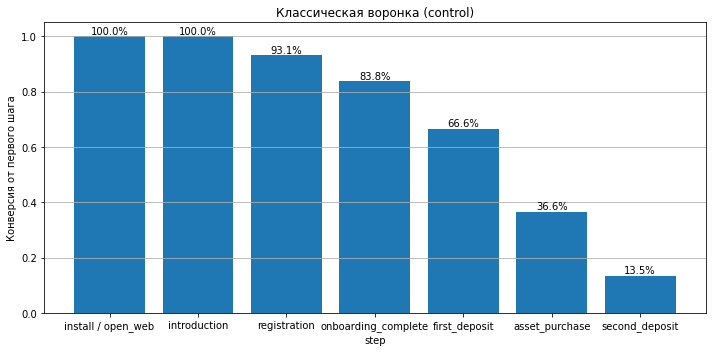

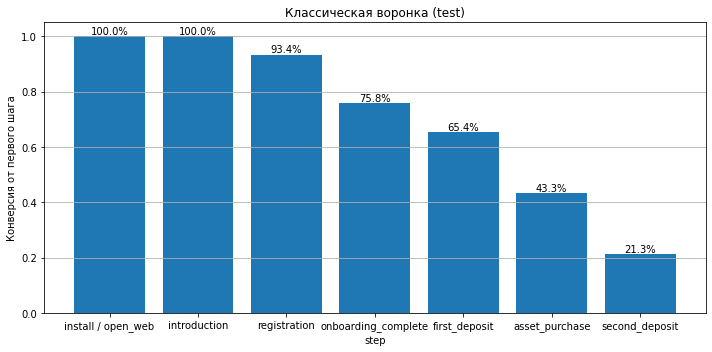

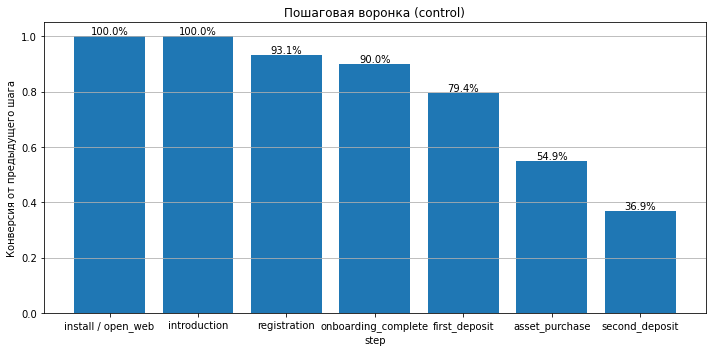

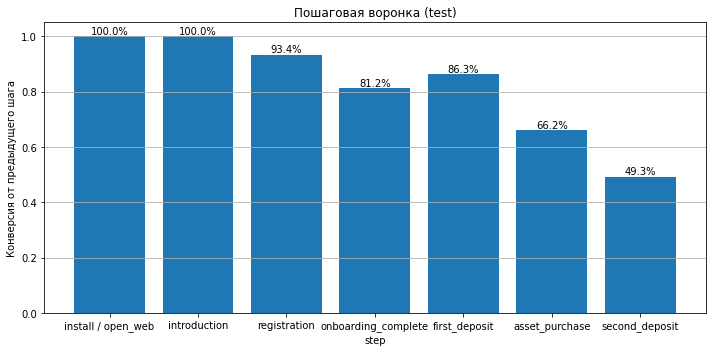

In [23]:
# Шаги воронки
steps = [
    'install / open_web',
    'introduction',
    'registration',
    'onboarding_complete',
    'first_deposit',
    'asset_purchase',
    'second_deposit'
]

# Группирую по step и группе A/B
funnel_counts = (
    df_abt[df_abt['event_name'].isin(steps)]
    .groupby(['group', 'event_name'])['user_id']
    .nunique()
    .reset_index()
)

# Переименовываю
funnel_counts.columns = ['group', 'step', 'users']

# Задаю правильный порядок 
funnel_counts['step'] = pd.Categorical(funnel_counts['step'], categories=steps, ordered=True)
funnel_counts = funnel_counts.sort_values(['group', 'step']).reset_index(drop=True)

# Классическая конверсия 
funnel_counts['conversion'] = funnel_counts.groupby('group')['users'].transform(lambda x: x / x.iloc[0])

# Пошаговая конверсия
funnel_counts['step_conversion'] = funnel_counts.groupby('group')['users'].transform(lambda x: x / x.shift(1))
funnel_counts.loc[funnel_counts.groupby('group').head(1).index, 'step_conversion'] = 1

display(funnel_counts)

# Визуализирую
for metric, ylabel, title_suffix in [
    ('conversion', 'Конверсия от первого шага', 'Классическая воронка'),
    ('step_conversion', 'Конверсия от предыдущего шага', 'Пошаговая воронка')
]:
    for grp in ['control', 'test']:
        df_plot = funnel_counts[funnel_counts['group'] == grp]
        plot_bar_with_labels(
            df_plot,
            x_col='step',
            y_col=metric,
            title=f'{title_suffix} ({grp})',
            ylabel=ylabel,
            is_percent=True
        )


В тестовой группе обновлённый, более подробный онбординг снижает конверсию на ранних этапах (от регистрации до завершения онбординга), что говорит о том, что часть пользователей он отпугивает. При этом пользователи, которые проходят онбординг, становятся более вовлечёнными: в тесте заметно выше конверсия из первого депозита в покупку активов и во второй депозит. В итоге фича ухудшает верх воронки, но улучшает поведение платящих пользователей.

В будущем, если обновление будет статистически значимым и его реализуют, стоит задуматься над некоторым упрощением онбординга, чтобы так же повысить конверсию ранних этапов.

,risk_level,users,users_with_second_deposit,conversion
1,low,285,142,0.498246
2,medium,595,265,0.445378
0,high,893,247,0.276596


,risk_level,users,users_with_second_deposit,conversion
1,low,496,285,0.574597
2,medium,744,350,0.470430
0,high,737,339,0.459973


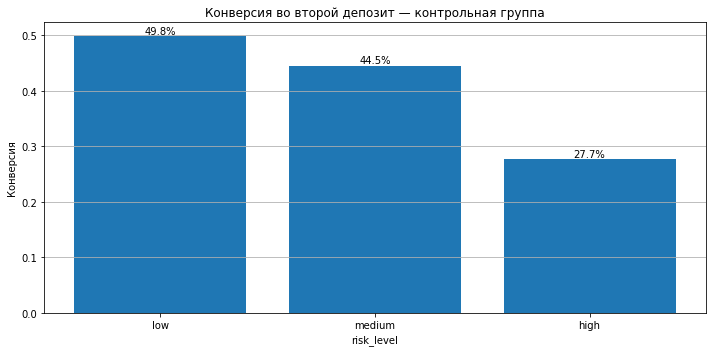

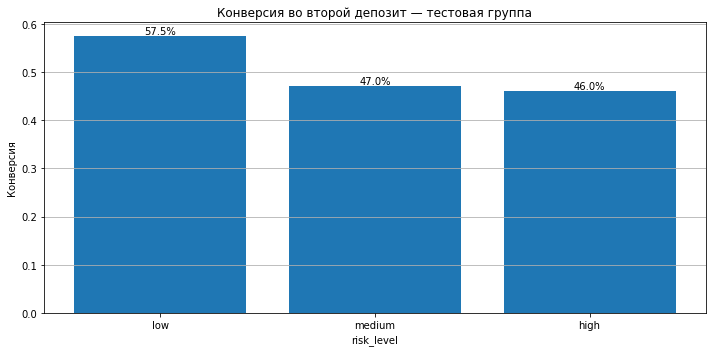

In [24]:
# Нахожу первый купленный актив каждого пользователя
first_asset = (
    df_abt[df_abt['event_name'] == 'asset_purchase']
    .sort_values('event_ts')  # сортируем по времени события
    .groupby('user_id', as_index=False)
    .first()[['user_id', 'risk_level', 'group']]  # оставляем риск и группу А/В
)

# Пользователи, у кого есть второй депозит
first_asset['has_second_deposit'] = first_asset['user_id'].isin(
    df_abt.loc[df_abt['event_name'] == 'second_deposit', 'user_id']
)

# Считаю конверсию для контрольной группы 
conversion_control = (
    first_asset[first_asset['group'] == 'control']
    .groupby('risk_level', observed=True)
    .agg(
        users=('user_id', 'nunique'),
        users_with_second_deposit=('has_second_deposit', 'sum')
    )
)
conversion_control['conversion'] = conversion_control['users_with_second_deposit'] / conversion_control['users']
conversion_control = conversion_control.reset_index()


# Задаю порядок столбцов
risk_order = ['low', 'medium', 'high']
conversion_control['risk_level'] = pd.Categorical(conversion_control['risk_level'], categories=risk_order, ordered=True)
conversion_control = conversion_control.sort_values('risk_level')


# Считаю конверсию для тестовой группы 
conversion_test = (
    first_asset[first_asset['group'] == 'test']
    .groupby('risk_level', observed=True)
    .agg(
        users=('user_id', 'nunique'),
        users_with_second_deposit=('has_second_deposit', 'sum')
    )
)
conversion_test['conversion'] = conversion_test['users_with_second_deposit'] / conversion_test['users']
conversion_test = conversion_test.reset_index()
conversion_test['risk_level'] = pd.Categorical(conversion_test['risk_level'], categories=risk_order, ordered=True)
conversion_test = conversion_test.sort_values('risk_level')



display(conversion_control)
display(conversion_test)

# Визуализирую графики
plot_bar_with_labels(
    conversion_control,
    x_col='risk_level',
    y_col='conversion',
    title='Конверсия во второй депозит — контрольная группа',
    ylabel='Конверсия',
    is_percent=True
)

plot_bar_with_labels(
    conversion_test,
    x_col='risk_level',
    y_col='conversion',
    title='Конверсия во второй депозит — тестовая группа',
    ylabel='Конверсия',
    is_percent=True
)

Новый онбординг повышает вероятность второго депозита у пользователей. Наибольший эффект наблюдается для пользователей с высоким уровнем риска — конверсия выросла с 27,7% в контроле до 46,0% в тесте. Для пользователей с низким и средним риском эффект тоже положительный, но менее выраженный: с 49,8% до 57,5% и с 44,5% до 47,0% соответственно.

Low риск

- H₀: конверсия во второй депозит для пользователей с low риском не отличается между контрольной и тестовой группой.

- H₁: конверсия во второй депозит для пользователей с low риском отличается между группами.

Medium риск

- H₀: конверсия во второй депозит для пользователей с medium риском не отличается между контрольной и тестовой группой.

- H₁: конверсия во второй депозит для пользователей с medium риском отличается между группами.

High риск

- H₀: конверсия во второй депозит для пользователей с high риском не отличается между контрольной и тестовой группой.

- H₁: конверсия во второй депозит для пользователей с high риском отличается между группами.

In [25]:
print("Статистическая значимость между группами по каждому уровню риска:")
for risk in ['low', 'medium', 'high']:
    control_row = conversion_control[conversion_control['risk_level'] == risk]
    test_row = conversion_test[conversion_test['risk_level'] == risk]
    
    count = [int(test_row['users_with_second_deposit']), int(control_row['users_with_second_deposit'])]
    nobs = [int(test_row['users']), int(control_row['users'])]
    
    stat, p_value = proportions_ztest(count, nobs)
    
    print(f"{risk.capitalize()} риск: Z-статистика = {stat:.2f}, p-value = {p_value:.4f}")

Статистическая значимость между группами по каждому уровню риска:
Low риск: Z-статистика = 2.06, p-value = 0.0391
Medium риск: Z-статистика = 0.91, p-value = 0.3607
High риск: Z-статистика = 7.68, p-value = 0.0000


Low риск: конверсия во второй депозит в тестовой группе статистически выше контрольной (p = 0.0391 < 0.05).

Medium риск: разница в конверсии между тестовой и контрольной группами незначима (p = 0.3607 > 0.05).

High риск: конверсия в тестовой группе значительно выше контрольной (p < 0.001).

То есть тест повлиял на пользователей с низким и высоким риском, а для среднего риска эффекта нет.

In [26]:
# Сумма депозитов на пользователя
deposit_per_user = df_abt.groupby(['group', 'user_id'])['amount'].sum().reset_index(name='sum_amount')

# Средняя сумма всех депозитов на пользователя в каждой группе
kpi = deposit_per_user.groupby('group')['sum_amount'].mean().reset_index(name='avg_deposit')
abs_delta = kpi['avg_deposit'][kpi['group']=='test'].values[0] - kpi['avg_deposit'][kpi['group']=='control'].values[0]
rel_delta = abs_delta / kpi['avg_deposit'][kpi['group']=='control'].values[0]

display(kpi)
print(f'Абсолютное изменение тест/контроль: {abs_delta:.2f}, относительное: {rel_delta:.2f}')

,group,avg_deposit
0,control,90.240149
1,test,92.460814


Абсолютное изменение тест/контроль: 2.22, относительное: 0.02


**Гипотеза роста**

- H₀: внедрение нового обучающего онбординга не влияет на конверсию во второй депозит.

- H₁: внедрение нового обучающего онбординга увеличивает конверсию во второй депозит.

In [27]:
# T-test для сравнения средних
# Передаём (test, control) и alternative='greater': проверяем, что тестовая > контрольной
test_data = deposit_per_user[deposit_per_user['group']=='test']['sum_amount']
control_data = deposit_per_user[deposit_per_user['group']=='control']['sum_amount']
stat, p_value = ttest_ind(test_data, control_data, alternative='greater')

print(f'p-value t-test: {p_value:.4f}')

# Вывод по статистической значимости
if p_value > 0.05:
    print("Нулевая гипотеза подтверждается: внедрение нового обучающего онбординга не влияет на конверсию во второй депозит.")
else:
    print("Нулевая гипотеза отвергается: внедрение нового обучающего онбординга увеличивает конверсию во второй депозит.")

p-value t-test: 0.1656
Нулевая гипотеза подтверждается: внедрение нового обучающего онбординга не влияет на конверсию во второй депозит.


### Кумулятивная динамика ключевой метрики по дням

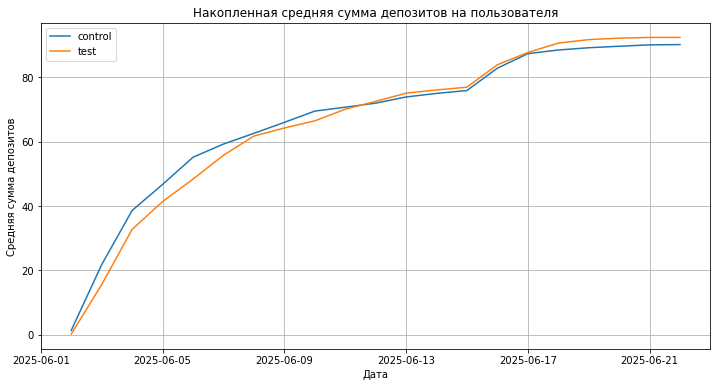

In [28]:
# Кумулятивная средняя сумма депозитов на пользователя
df_abt['event_date'] = df_abt['event_ts'].dt.date  # преобразуем в дату

all_dates = sorted(df_abt['event_date'].unique())
cum_kpi_list = []

for current_date in all_dates:
    # События до текущей даты 
    df_to_date = df_abt[df_abt['event_date'] <= current_date]

    # Сумма депозитов на пользователя
    deposit_to_date = df_to_date.groupby(['group', 'user_id'])['amount'].sum().reset_index(name='sum_amount')
    
    # Среднее на пользователя по группе
    daily_kpi = deposit_to_date.groupby('group')['sum_amount'].mean().reset_index(name='avg_deposit')
    daily_kpi['date'] = current_date
    cum_kpi_list.append(daily_kpi)

# Собираю датафрейм
cum_kpi_df = pd.concat(cum_kpi_list)

# print(cum_kpi_df)

# Визуализация
plt.figure(figsize=(12,6))
for group in cum_kpi_df['group'].unique():
    df_plot = cum_kpi_df[cum_kpi_df['group']==group]
    plt.plot(df_plot['date'], df_plot['avg_deposit'], label=group)
plt.title("Накопленная средняя сумма депозитов на пользователя")
plt.xlabel("Дата")
plt.ylabel("Средняя сумма депозитов")
plt.legend()
plt.grid(True)
plt.show()


На старте эксперимента контрольная группа показывала среднюю сумму депозитов выше тестовой.

К концу наблюдаемого периода средняя кумулятивная сумма депозитов тестовой группы стабильно выше контрольной.

В целом динамика показывает постепенное сокращение отставания тестовой группы и выход на опережение, что говорит о положительном эффекте эксперимента на средний депозит на пользователя.

Динамика p-value по дням.

          date   p_value
0   2025-06-02  0.965758
1   2025-06-03  0.992228
2   2025-06-04  0.981788
3   2025-06-05  0.977673
4   2025-06-06  0.995061
5   2025-06-07  0.905729
6   2025-06-08  0.628051
7   2025-06-09  0.757683
8   2025-06-10  0.894574
9   2025-06-11  0.605774
10  2025-06-12  0.403907
11  2025-06-13  0.302471
12  2025-06-14  0.311215
13  2025-06-15  0.310661
14  2025-06-16  0.310083
15  2025-06-17  0.432314
16  2025-06-18  0.170551
17  2025-06-19  0.131976
18  2025-06-20  0.134114
19  2025-06-21  0.155526
20  2025-06-22  0.165647


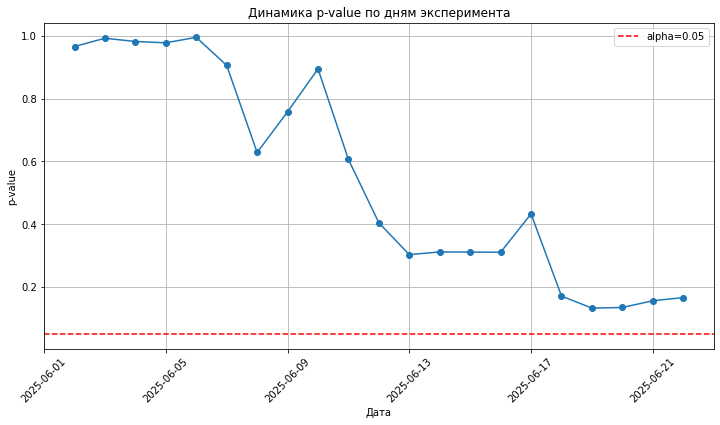

In [29]:
pval_list = []

for current_date in all_dates:
    df_to_date = df_abt[df_abt['event_date'] <= current_date]
    deposit_to_date = df_to_date.groupby(['group', 'user_id'])['amount'].sum().reset_index(name='sum_amount')
    
    # t-test для p-value
    test_day = deposit_to_date[deposit_to_date['group']=='test']['sum_amount']
    control_day = deposit_to_date[deposit_to_date['group']=='control']['sum_amount']
    stat_day, p_day = ttest_ind(test_day, control_day, alternative='greater')  # тестовая > контрольной
    pval_list.append({'date': current_date, 'p_value': p_day})

# Собираю датафрейм
pval_df = pd.DataFrame(pval_list)

print(pval_df)

# Визуализация 
plt.figure(figsize=(12,6))
plt.plot(pval_df['date'], pval_df['p_value'], marker='o')
plt.axhline(0.05, color='red', linestyle='--', label='alpha=0.05')
plt.title("Динамика p-value по дням эксперимента")
plt.xlabel("Дата")
plt.ylabel("p-value")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.show()

В целом, p-value показывает высокую нестабильность в первые дни, затем снижается, но ни разу не становится <0.05, следовательно, разница между группами не подтверждается статистически на протяжении всего периода.

### Барьерная метрика: конверсия из регистрации в первый депозит

In [30]:
# Барьерная метрика: конверсия из регистрации в первый депозит
registered = df_abt[df_abt['event_name']=='registration']
first_deposit = df_abt[df_abt['event_name']=='first_deposit']
first_deposit = first_deposit[first_deposit['user_id'].isin(registered['user_id'])]

reg_count = registered.groupby('group')['user_id'].nunique()
purch_count = first_deposit.groupby('group')['user_id'].nunique()

funnel_df = pd.DataFrame({
    'registered': reg_count,
    'first_deposit': purch_count
})
funnel_df['conversion'] = funnel_df['first_deposit'] / funnel_df['registered']
display(funnel_df)

# Считаю абсолютные и относительные изменения 
abs_delta_conversion = funnel_df['conversion'].iloc[1] - funnel_df['conversion'].iloc[0]
rel_delta_conversion = abs_delta_conversion / funnel_df['conversion'].iloc[0]
print(f'Абсолютное изменение значений в тестовой группе по сравнению с контрольной  {abs_delta_conversion:.4f}, относительное  {rel_delta_conversion:.4f}')

,registered,first_deposit,conversion
group,,,
control,4512,3228,0.715426
test,4265,2987,0.700352


Абсолютное изменение значений в тестовой группе по сравнению с контрольной  -0.0151, относительное  -0.0211


**Гипотеза риска**

- H₀: информация о возможных потерях и высоких рисках не влияет на конверсию в первый депозит у новичков.

- H₁: информация о возможных потерях и высоких рисках снижает конверсию в первый депозит у новичков.

In [31]:
# Z-test пропорций для барьерной метрики
# Барьерная метрика -- проверяем что конверсия не ухудшилась, используем двусторонний тест
count = funnel_df['first_deposit'].values
nobs = funnel_df['registered'].values
stat_z, p_z = proportions_ztest(count, nobs, alternative='two-sided')

# Вывод по статистической значимости
if p_z < 0.05:
    print(f'Барьерная метрика статистически значима (p-value={p_z:.4f}), конверсия изменилась')
else:
    print(f'Барьерная метрика статистически не значима (p-value={p_z:.4f}), конверсия не ухудшилась')

Барьерная метрика не статистически значима (p-value=0.9397), конверсия не ухудшилась


### Вспомогательная метрика 1: конверсия из первого депозита во второй

In [32]:
# Пользователей со вторыми депозитами
second_deposit = df_abt[df_abt['event_name'] == 'second_deposit']
second_deposit = second_deposit[second_deposit['user_id'].isin(first_deposit['user_id'])]

# Считаю пользователей по группе
first_count = first_deposit.groupby('group')['user_id'].nunique()
second_count = second_deposit.groupby('group')['user_id'].nunique()

funnel_second_df = pd.DataFrame({
    'first_deposit': first_count,
    'second_deposit': second_count
})
# Конверсия
funnel_second_df['conversion'] = funnel_second_df['second_deposit'] / funnel_second_df['first_deposit']

display(funnel_second_df)

# Абсолютное и относительное изменение
abs_delta_conversion_2 = funnel_second_df['conversion'].iloc[1] - funnel_second_df['conversion'].iloc[0]
rel_delta_conversion_2 = abs_delta_conversion_2 / funnel_second_df['conversion'].iloc[0]
print(f'Абсолютное изменение значений в тестовой группе по сравнению с контрольной  {abs_delta_conversion_2:.4f}, относительное  {rel_delta_conversion_2:.4f}')

,first_deposit,second_deposit,conversion
group,,,
control,3228,654,0.202602
test,2987,974,0.326080


Абсолютное изменение значений в тестовой группе по сравнению с контрольной  0.1235, относительное  0.6095


**Дополнительная гипотеза 1** (конверсия из первого депозита во второй)

- H₀: после нового онбординга пользователи, выбирающие высокорискованные активы, не изменяют частоту открытия второго депозита.

- H₁: после нового онбординга пользователи, выбирающие высокорискованные активы, чаще открывают второй депозит.

In [33]:
# Z-test пропорций для вспомогательной метрики 1
# Передаём (test, control) и alternative='larger': проверяем что тестовая конверсия выше
count2 = [funnel_second_df.loc['test', 'second_deposit'], funnel_second_df.loc['control', 'second_deposit']]
nobs2 = [funnel_second_df.loc['test', 'first_deposit'], funnel_second_df.loc['control', 'first_deposit']]
stat_z2, p_z2 = proportions_ztest(count2, nobs2, alternative='larger')

# Вывод по статистической значимости
if p_z2 < 0.05:
    print(f'Вспомогательная метрика конверсии статистически значима (p-value={p_z2:.4f}), метрика улучшилась')
else:
    print(f'Вспомогательная метрика конверсии не статистически значима (p-value={p_z2:.4f}), метрика не улучшилась')

Вспомогательная метрика конверсии статистически значима (p-value=0.0000), метрика улучшилась


### Вспомогательная метрика 2: средняя сумма депозитов на платящего пользователя

In [34]:
# Пользователей с депозитами
deposit_users = df_abt[df_abt['amount'] > 0].groupby(['group', 'user_id'])['amount'].sum().reset_index(name='sum_amount')

# Средняя сумма на пользователя по группе
kpi_deposit = deposit_users.groupby('group')['sum_amount'].mean().reset_index(name='avg_deposit')

# Абсолютное и относительное изменение
abs_delta2 = kpi_deposit['avg_deposit'][kpi_deposit['group']=='test'].values[0] - kpi_deposit['avg_deposit'][kpi_deposit['group']=='control'].values[0]
rel_delta2 = abs_delta2 / kpi_deposit['avg_deposit'][kpi_deposit['group']=='control'].values[0]

display(kpi_deposit)
print(f'Абсолютное изменение тест/контроль: {abs_delta2:.2f}, относительное: {rel_delta2:.2f}')


,group,avg_deposit
0,control,135.500000
1,test,141.399732


Абсолютное изменение тест/контроль: 5.90, относительное: 0.04


**Дополнительная гипотеза 2** (средняя сумма депозитов на пользователя, который открыл хотя бы один депозит)

- H₀: внедрение нового онбординга не влияет на среднюю сумму депозитов на пользователя, который совершил хотя бы один депозит.

- H₁: внедрение нового онбординга увеличивает среднюю сумму депозитов на пользователя, который совершил хотя бы один депозит.

In [35]:
# t-test для сравнения средних
# Передаём (test, control) и alternative='greater': проверяем что тестовая > контрольной
test_data2 = deposit_users[deposit_users['group']=='test']['sum_amount']
control_data2 = deposit_users[deposit_users['group']=='control']['sum_amount']

stat2, p_value2 = ttest_ind(test_data2, control_data2, alternative='greater')

# Вывод по статистической значимости
if p_value2 < 0.05:
    print(f'Вспомогательная метрика 2 (средняя сумма на депозитора) статистически значима (p-value={p_value2:.4f}), метрика улучшилась')
else:
    print(f'Вспомогательная метрика 2 (средняя сумма на депозитора) НЕ статистически значима (p-value={p_value2:.4f}), метрика не улучшилась')

Вспомогательная метрика 2 (средняя сумма на депозиторa) статистически значима (p-value=0.0173), метрика улучшилась


 **Ключевая метрика** (средняя сумма всех депозитов на пользователя)

**p-value t-test = 0.1656** - нулевая гипотеза подтверждается, разницы между группами нет.  

Динамика показывает постепенное сокращение отставания тестовой группы и выход на опережение, положительный эффект наблюдается, но статистически он не подтвержден.  

---

 **Барьерная метрика** (конверсия из регистрации в первый депозит)

**Контроль:** 0.7154  
**Тест:** 0.7004  

**p-value = 0.9397** - статистически значимой разницы нет, конверсия не ухудшилась.  

---

 **Вспомогательная метрика 1** (конверсия из первого депозита во второй)

**Контроль:** 0.2026  
**Тест:** 0.3261  

**p-value = 0.0000** - статистически значимо, метрика улучшилась.  

---

 **Вспомогательная метрика 2** (средняя сумма депозитов на пользователя)

**Контроль:** 135.50  
**Тест:** 141.40  

**p-value = 0.0173** - статистически значимо, средний депозит на пользователя увеличился.  

---

 **Общий вывод**

Эксперимент показал статистически значимое улучшение вспомогательных метрик.  
Ключевая и барьерная метрики пока не достигли статистической значимости, но динамика ключевой метрики положительная, что указывает на потенциальный положительный эффект эксперимента.


---

### 4. Анализ изменений суммы депозитов на платящего пользователя

Предыдущий раздел проверял гипотезы на уровне средних и пропорций. Этот раздел дополняет картину: с помощью бутстрапа исследуется, как новый онбординг изменил распределение депозитов внутри платящей аудитории — отдельно для нижнего и верхнего сегментов.

--- 25-й перцентиль ---
Контроль: 95.00
Тест: 48.00
Средняя разница (тест - контроль): -46.86
95%-й доверительный интервал разницы: [-50.00, -44.00]



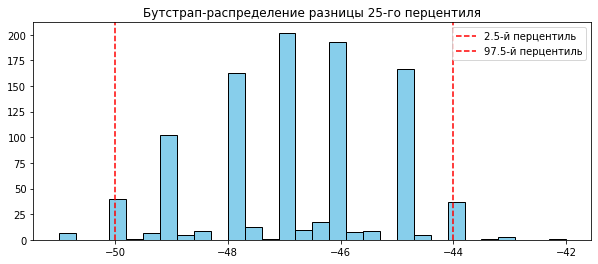

--- 50-й перцентиль ---
Контроль: 118.00
Тест: 94.00
Средняя разница (тест - контроль): -23.36
95%-й доверительный интервал разницы: [-27.00, -19.00]



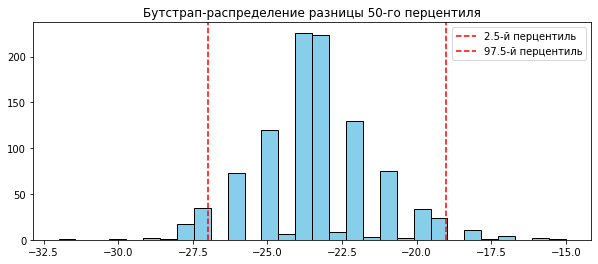

--- 75-й перцентиль ---
Контроль: 159.00
Тест: 179.50
Средняя разница (тест - контроль): 20.62
95%-й доверительный интервал разницы: [11.00, 30.00]



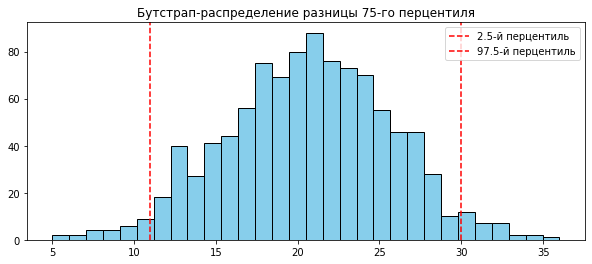

In [36]:
# Фиксирую сид для воспроизводимости
np.random.seed(341) 

# Фильтрую платящих пользователей
control = df_abt[(df_abt['group']=='control') & (df_abt['amount']>0)]
test = df_abt[(df_abt['group']=='test') & (df_abt['amount']>0)]

# Сумма депозитов на каждого платящего пользователя
control_sums = control.groupby('user_id')['amount'].sum()
test_sums = test.groupby('user_id')['amount'].sum()

# Перцентили для анализа
percentiles = [25, 50, 75]
n_iterations = 1000

for p in percentiles:
    boot_diffs = []
    
    for _ in range(n_iterations):
        boot_control = np.random.choice(control_sums, size=len(control_sums), replace=True)
        boot_test = np.random.choice(test_sums, size=len(test_sums), replace=True)
        
        control_p = np.percentile(boot_control, p)
        test_p = np.percentile(boot_test, p)
        boot_diffs.append(test_p - control_p)
    
    boot_diffs = np.array(boot_diffs)
    diff_ci = np.percentile(boot_diffs, [2.5, 97.5])
    
    # Вывод доверительных интервалов
    print(f"--- {p}-й перцентиль ---")
    print(f"Контроль: {np.percentile(control_sums, p):.2f}")
    print(f"Тест: {np.percentile(test_sums, p):.2f}")
    print(f"Средняя разница (тест - контроль): {np.mean(boot_diffs):.2f}")
    print(f"95%-й доверительный интервал разницы: [{diff_ci[0]:.2f}, {diff_ci[1]:.2f}]\n")
    
    # Визуализация бутстрап-распределения
    plt.figure(figsize=(10,4))
    plt.hist(boot_diffs, bins=30, color='skyblue', edgecolor='black')
    plt.axvline(diff_ci[0], color='red', linestyle='--', label='2.5-й перцентиль')
    plt.axvline(diff_ci[1], color='red', linestyle='--', label='97.5-й перцентиль')
    plt.title(f"Бутстрап-распределение разницы {p}-го перцентиля")
    plt.legend()
    plt.show()

Bootstrap-анализ показал поляризацию поведения платящих пользователей: нижний сегмент (25-й и 50-й перцентили) стал вносить меньше — снижение статистически значимо. Верхний сегмент (75-й перцентиль) вырос на 21 единицу, что также статистически значимо.

Медиана могла снизиться из-за повышенной осторожности у большинства новых пользователей, которые раньше меньше задумывались о рисках и последствиях в инвестициях, рассчитывая на быстрый доход. Подробный онбординг отрезвил этот сегмент, тогда как вовлечённые инвесторы стали активнее.

Новый онбординг изменил поведение пользователей дифференцировано: это важный сегментационный инсайт для продукта.

---

### 5. Выводы

**Общий эффект обновленного онбординга:** он не ухудшил ключевые показатели продукта.

**Барьерная метрика** (конверсия из регистрации в первый депозит):
- Не изменилась статистически значимо, что подтверждает отсутствие негативного влияния на вовлечение новых пользователей.

**Вспомогательные метрики:**

- Конверсия из первого депозита во второй увеличилась с 20% до 33% (p < 0.001) в тестовой группе, статистически значимо. Это большой эффект.

- Средняя сумма депозитов на пользователя, который сделал хотя бы один депозит, повысилась на 4% (статистически значимо, p=0.0173).

**Распределение депозитов:**

- 25-й и 50-й перцентили в тестовой группе снизились, что говорит о сокращении небольших и средних сумм.

- 75-й перцентиль вырос на 21 единицу, что демонстрирует повышение вовлечённости крупных платящих пользователей.

**Ключевая метрика** (средняя сумма всех депозитов на пользователя)

- Увеличение на 2% в тестовой группе, но статистически незначимо (p=0.1656).

- Кумулятивная динамика по дням и p-value показывают положительную тенденцию, однако различие между группами не подтверждается статистически. Вероятно, двух недель эксперимента недостаточно для стабилизации этой метрики.

**Рекомендация: внедрить с мониторингом**

Данные поддерживают внедрение нового онбординга: вспомогательные метрики улучшились статистически значимо, ключевая метрика показывает положительную тенденцию при отсутствии значимого ухудшения барьерной.

Риск: нижний сегмент платящих пользователей снизил суммы депозитов. При внедрении стоит отслеживать удержание этого сегмента и при необходимости тестировать упрощённую версию онбординга для менее вовлечённых пользователей.